# RNN Theory, Concepts, Types, and Training Pipeline in PyTorch

This notebook is  study notebook for learning Recurrent Neural Networks (RNNs).  
The goal is to understand the theory first, then connect the theory with a simple PyTorch training pipeline.

We will cover:

- What an RNN is and why we use it
- Sequence data and tensor shapes
- Hidden state and memory
- Common RNN input-output patterns
- Main RNN types: Vanilla RNN, LSTM, GRU, Bidirectional RNN, Stacked RNN, and Seq2Seq RNN
- Full training pipeline in PyTorch
- A small practice dataset for sequence classification
- Model comparison between RNN, LSTM, GRU, and Bidirectional LSTM

## What is a Recurrent Neural Network?

A Recurrent Neural Network is a neural network designed for sequence data.

Sequence data means the order matters. Examples include:

| Data type | Sequence example |
|---|---|
| Text | words in a sentence |
| Music | notes over time |
| Stock data | prices over days |
| Sensor data | readings over time |
| Speech | sound frames over time |

A normal feed-forward neural network treats inputs as independent. An RNN reads data step by step and keeps a hidden state. The hidden state works like a small memory of previous steps.

## Important RNN idea: hidden state

At every time step, the RNN receives:

1. the current input
2. the previous hidden state

Then it creates:

1. the current output
2. the new hidden state

Simple formula:

\[
h_t = f(W_x x_t + W_h h_{t-1} + b)
\]

Where:

- \(x_t\) = input at time step \(t\)
- \(h_{t-1}\) = previous hidden state
- \(h_t\) = current hidden state
- \(W_x\) = input weight
- \(W_h\) = hidden weight
- \(b\) = bias
- \(f\) = activation function, often `tanh`

The hidden state allows the network to remember earlier information.

## Shape of sequence data

In PyTorch, when we use `batch_first=True`, our RNN input shape is:

```text
(batch_size, sequence_length, input_size)
```

Meaning:

| Shape part | Meaning |
|---|---|
| batch_size | how many samples we process together |
| sequence_length | how many time steps each sample has |
| input_size | how many features each time step has |

Example:

```text
(32, 10, 5)
```

This means:

- 32 samples in one batch
- each sample has 10 time steps
- each time step has 5 features

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# We set a seed so our results stay similar when we run the notebook again.
torch.manual_seed(1717)

# This keeps small CPU-based LSTM examples stable in  notebook environments.
torch.backends.mkldnn.enabled = False

## RNN input-output patterns

RNNs can be used in different ways depending on the task.

| Pattern | Input | Output | Example |
|---|---|---|---|
| One-to-one | one input | one output | normal image classification, not really RNN-style |
| One-to-many | one input | sequence output | image caption generation |
| Many-to-one | sequence input | one output | sentiment classification |
| Many-to-many, same length | sequence input | sequence output | part-of-speech tagging |
| Many-to-many, different length | sequence input | sequence output | machine translation |

In our practice pipeline, we will use **many-to-one** classification.

## Main types of RNNs

Below are the main types we should know while learning RNNs.

| RNN type | Main idea | Good for | Main limitation |
|---|---|---|---|
| Vanilla RNN | simplest recurrent model | short sequences | struggles with long memory |
| LSTM | uses gates and cell state | longer sequences | more parameters |
| GRU | simpler gated model than LSTM | medium or long sequences | sometimes less powerful than LSTM |
| Bidirectional RNN | reads sequence forward and backward | when full sequence is available | not suitable for real-time future prediction |
| Stacked or Deep RNN | multiple RNN layers | complex patterns | more training cost |
| Seq2Seq RNN | encoder-decoder structure | translation, summarization, chatbot | may need attention for long inputs |
| Attention RNN | focuses on important time steps | longer seq2seq tasks | more complex than basic RNN |

We will code the most common beginner-level models: Vanilla RNN, LSTM, GRU, Bidirectional LSTM, and Stacked GRU.

## Vanilla RNN theory

A Vanilla RNN is the simplest RNN.

It reads the sequence step by step and updates the hidden state each time.

Strengths:

- simple to understand
- easy to implement
- useful for short sequences

Weaknesses:

- vanishing gradient problem
- exploding gradient problem
- weak long-term memory

Vanishing gradient means earlier time steps may become hard to learn from during training.

In [2]:
# Vanilla RNN model for binary sequence classification

class VanillaRNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(VanillaRNNClassifier, self).__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, hidden = self.rnn(x)

        # We take the output from the last time step.
        last_output = out[:, -1, :]

        out = self.fc(last_output)
        out = self.sigmoid(out)

        return out

## LSTM theory

LSTM means Long Short-Term Memory.

LSTM was designed to reduce the long-memory problem of Vanilla RNN.

It has three important gates:

| Gate | Meaning |
|---|---|
| Forget gate | decides what old information we remove |
| Input gate | decides what new information we add |
| Output gate | decides what information we send forward |

LSTM also has a **cell state**, which works like a stronger memory path.

LSTM is useful when the sequence is longer and earlier information matters.

In [3]:
# LSTM model for binary sequence classification

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMClassifier, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, (hidden, cell) = self.lstm(x)

        last_output = out[:, -1, :]

        out = self.fc(last_output)
        out = self.sigmoid(out)

        return out

## GRU theory

GRU means Gated Recurrent Unit.

GRU is similar to LSTM, but it is simpler.

It mainly uses:

| Gate | Meaning |
|---|---|
| Update gate | decides how much old information we keep |
| Reset gate | decides how much previous memory we ignore |

GRU usually trains faster than LSTM because it has fewer parameters.

GRU is a good first choice when we want a stronger model than Vanilla RNN but still want simpler training than LSTM.

In [4]:
# GRU model for binary sequence classification

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(GRUClassifier, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, hidden = self.gru(x)

        last_output = out[:, -1, :]

        out = self.fc(last_output)
        out = self.sigmoid(out)

        return out

## Bidirectional RNN theory

A normal RNN reads from left to right.

A Bidirectional RNN reads in two directions:

1. forward direction
2. backward direction

This helps when the model can use both past and future context.

Example:

In a sentence, a word may depend on words before it and after it.

Important note: Bidirectional RNN is not suitable when future values are not available, such as live prediction or real-time forecasting.

In [5]:
# Bidirectional LSTM model for binary sequence classification

class BidirectionalLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(BidirectionalLSTMClassifier, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

        # Because the LSTM is bidirectional, output size becomes hidden_size * 2.
        self.fc = nn.Linear(hidden_size * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, (hidden, cell) = self.lstm(x)

        last_output = out[:, -1, :]

        out = self.fc(last_output)
        out = self.sigmoid(out)

        return out

## Stacked or Deep RNN theory

A stacked RNN has more than one recurrent layer.

The first RNN layer learns lower-level sequence patterns. The next RNN layer learns higher-level sequence patterns.

In PyTorch, we can create a stacked RNN by using:

```python
num_layers=2
```

Stacked RNN can learn more complex sequence patterns, but it may also overfit or train more slowly.

In [6]:
# Stacked GRU model for binary sequence classification

class StackedGRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(StackedGRUClassifier, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, hidden = self.gru(x)

        last_output = out[:, -1, :]

        out = self.fc(last_output)
        out = self.sigmoid(out)

        return out

## Seq2Seq RNN theory

Seq2Seq means sequence-to-sequence.

It has two parts:

1. **Encoder**: reads the input sequence and creates a context representation
2. **Decoder**: uses the context representation to generate an output sequence

Seq2Seq is used for:

- translation
- summarization
- chatbot response generation
- text generation
- music generation

A simple Seq2Seq model may struggle with long input sequences. Attention can help by letting the decoder focus on important encoder time steps.

We do not train a full Seq2Seq model in this beginner notebook because our current goal is to build a strong foundation first.

## Full RNN training pipeline

Our training pipeline has these steps:

1. Prepare sequence data
2. Split data into training and testing sets
3. Create DataLoader
4. Build the RNN model
5. Choose loss function
6. Choose optimizer
7. Train for several epochs
8. Calculate loss
9. Backpropagate
10. Update weights
11. Evaluate accuracy
12. Save or reuse the model

This is the same general pipeline used in real neural network projects.

## Step 1: Create a simple practice dataset

We will create a small artificial sequence-classification dataset.

Each sample has:

```text
sequence_length = 10
input_size = 5
```

So each sample shape is:

```text
(10, 5)
```

The label rule is simple:

- if the sum of the last time step is greater than 0, label = 1
- otherwise, label = 0

This gives our model a pattern to learn.

In [7]:
# Dataset settings

num_samples = 1000
sequence_length = 10
input_size = 5

# We create random sequence data.
X = torch.randn(num_samples, sequence_length, input_size)

# We create labels from the last time step.
last_step = X[:, -1, :]
last_step_sum = last_step.sum(dim=1)

# If the sum is greater than 0, class is 1. Otherwise, class is 0.
y = (last_step_sum > 0).float()

# We reshape y to match model output shape: (batch_size, 1)
y = y.view(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First label:", y[0].item())

X shape: torch.Size([1000, 10, 5])
y shape: torch.Size([1000, 1])
First label: 1.0


## Step 2: Split data into training and testing sets

We use most of the data for training and the remaining part for testing.

In [8]:
# Train-test split

train_size = 800

a = X[:train_size]
b = y[:train_size]

c = X[train_size:]
d = y[train_size:]

X_train = a
y_train = b
X_test = c
y_test = d

print("Training X:", X_train.shape)
print("Training y:", y_train.shape)
print("Testing X:", X_test.shape)
print("Testing y:", y_test.shape)

Training X: torch.Size([800, 10, 5])
Training y: torch.Size([800, 1])
Testing X: torch.Size([200, 10, 5])
Testing y: torch.Size([200, 1])


## Step 3: Create DataLoader

DataLoader helps us train in mini-batches.

Instead of sending all 800 training samples at once, we send smaller groups such as 32 samples at a time.

In [9]:
# DataLoader setup

batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for batch_X, batch_y in train_loader:
    print("One batch X shape:", batch_X.shape)
    print("One batch y shape:", batch_y.shape)
    break

One batch X shape: torch.Size([32, 10, 5])
One batch y shape: torch.Size([32, 1])


## Step 4: Choose a model

We start with GRU because it is stronger than Vanilla RNN and simpler than LSTM.

In [10]:
# Model settings

hidden_size = 16

model = GRUClassifier(input_size=input_size, hidden_size=hidden_size)

print(model)

GRUClassifier(
  (gru): GRU(5, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Count trainable parameters

Trainable parameters are the weights and biases that our model updates during training.

In [11]:
# Count trainable parameters

total_params = 0

for name, param in model.named_parameters():
    if param.requires_grad:
        number = param.numel()
        total_params = total_params + number
        print(name, "=", number, "parameters", list(param.shape))

print("Total trainable parameters:", total_params)

gru.weight_ih_l0 = 240 parameters [48, 5]
gru.weight_hh_l0 = 768 parameters [48, 16]
gru.bias_ih_l0 = 48 parameters [48]
gru.bias_hh_l0 = 48 parameters [48]
fc.weight = 16 parameters [1, 16]
fc.bias = 1 parameters [1]
Total trainable parameters: 1121


## Step 5: Choose loss function and optimizer

Because this is binary classification, we use Binary Cross Entropy loss.

Because our model output passes through sigmoid, we use:

```python
nn.BCELoss()
```

For optimization, we use Adam because it is common and beginner-friendly.

In [12]:
# Loss and optimizer

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

## Step 6: Training loop

During training, we repeat these steps:

1. send a batch into the model
2. calculate prediction
3. calculate loss
4. clear old gradients
5. backpropagate
6. clip gradients to reduce exploding gradients
7. update weights
8. store average loss

In [13]:
# Training loop

num_epochs = 10
loss_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for batch_X, batch_y in train_loader:
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping helps reduce exploding gradient problems.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss = running_loss + loss.item()

    average_loss = running_loss / len(train_loader)
    loss_history.append(average_loss)

    print("Epoch:", epoch + 1, "Loss:", round(average_loss, 4))

Epoch: 1 Loss: 0.5554
Epoch: 2 Loss: 0.2308
Epoch: 3 Loss: 0.11
Epoch: 4 Loss: 0.0816
Epoch: 5 Loss: 0.0704
Epoch: 6 Loss: 0.0577
Epoch: 7 Loss: 0.0558
Epoch: 8 Loss: 0.0497
Epoch: 9 Loss: 0.0429
Epoch: 10 Loss: 0.0372


## Plot training loss

A good training loss curve should usually go downward.

If loss does not decrease, we may need to check:

- learning rate
- data labels
- model size
- number of epochs
- preprocessing

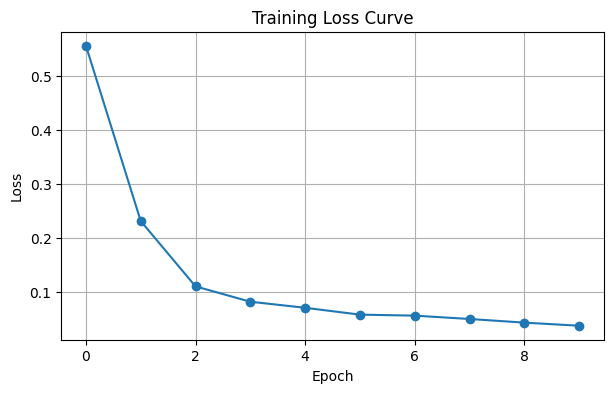

In [14]:
# Plot loss curve

plt.figure(figsize=(7, 4))
plt.plot(loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

## Step 7: Evaluate the model

For binary classification:

- sigmoid output above or equal to 0.5 becomes class 1
- sigmoid output below 0.5 becomes class 0

In [15]:
# Evaluation

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)
        predicted_classes = (predictions >= 0.5).float()

        correct = correct + (predicted_classes == batch_y).sum().item()
        total = total + batch_y.size(0)

accuracy = correct / total

print("Test accuracy:", round(accuracy * 100, 2), "%")

Test accuracy: 98.0 %


## Optional: compare multiple RNN types

Now we compare four models using the same dataset:

1. Vanilla RNN
2. LSTM
3. GRU
4. Bidirectional LSTM

We use a small helper function only to avoid repeating the same training code many times.

In [16]:
# Helper function for model comparison

def train_and_evaluate(model, train_loader, test_loader, epochs):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        model.train()

        for batch_X, batch_y in train_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            predictions = model(batch_X)
            predicted_classes = (predictions >= 0.5).float()

            correct = correct + (predicted_classes == batch_y).sum().item()
            total = total + batch_y.size(0)

    accuracy = correct / total
    return accuracy

In [17]:
# Compare model types

hidden_size = 16
comparison_epochs = 5

models = [
    ("Vanilla RNN", VanillaRNNClassifier(input_size, hidden_size)),
    ("LSTM", LSTMClassifier(input_size, hidden_size)),
    ("GRU", GRUClassifier(input_size, hidden_size)),
    ("Bidirectional LSTM", BidirectionalLSTMClassifier(input_size, hidden_size))
]

results = []

for model_name, model_item in models:
    acc = train_and_evaluate(model_item, train_loader, test_loader, comparison_epochs)
    results.append((model_name, acc))
    print(model_name, "accuracy:", round(acc * 100, 2), "%")

Vanilla RNN accuracy: 99.5 %
LSTM accuracy: 94.0 %
GRU accuracy: 98.5 %
Bidirectional LSTM accuracy: 98.0 %


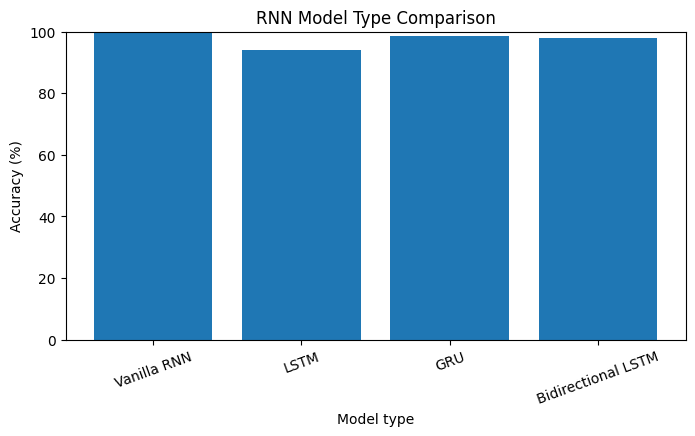

In [18]:
# Show comparison result as a simple bar chart

names = []
accuracies = []

for item in results:
    names.append(item[0])
    accuracies.append(item[1] * 100)

plt.figure(figsize=(8, 4))
plt.bar(names, accuracies)
plt.xlabel("Model type")
plt.ylabel("Accuracy (%)")
plt.title("RNN Model Type Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.show()

## Important RNN training problems

### 1. Vanishing gradient

Older information becomes weak during backpropagation. Vanilla RNN has this problem more often.

Common solutions:

- use LSTM
- use GRU
- use shorter sequences
- use better initialization

### 2. Exploding gradient

Gradients become too large and training becomes unstable.

Common solution:

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

### 3. Overfitting

The model performs well on training data but poorly on new data.

Common solutions:

- use more data
- reduce model size
- add dropout
- use validation data
- stop training earlier

### 4. Wrong tensor shape

Many RNN errors happen because the input shape is wrong.

With `batch_first=True`, we must keep:

```text
(batch_size, sequence_length, input_size)
```

## When should we use each RNN type?

| Situation | Good choice |
|---|---|
| very simple short sequence | Vanilla RNN |
| sequence has longer memory | LSTM |
| we want faster training than LSTM | GRU |
| full sentence or full sequence is available | Bidirectional LSTM or Bidirectional GRU |
| pattern is complex | Stacked LSTM or Stacked GRU |
| input sequence and output sequence have different lengths | Seq2Seq RNN |
| long seq2seq task | Seq2Seq with attention |

For many beginner projects, GRU is a good starting point because it is simple and effective.

## RNN training pipeline checklist

Before training any RNN, we can check these items:

- Our input is sequence data
- Our tensor shape is correct
- Our labels match the task
- Our model output size matches the label size
- Our loss function matches the problem type
- Our optimizer has a suitable learning rate
- Our training loop includes `zero_grad()`, `backward()`, and `step()`
- Our evaluation uses `torch.no_grad()`
- Our accuracy calculation matches the output type

## Small practice template

We can reuse this template for future RNN projects.

In [19]:
# Simple RNN project template

# 1. Import libraries
# 2. Load or create sequence data
# 3. Convert data into tensor shape: (batch, sequence_length, input_size)
# 4. Split data into train and test sets
# 5. Create TensorDataset and DataLoader
# 6. Build RNN, LSTM, or GRU model
# 7. Choose loss function
# 8. Choose optimizer
# 9. Train the model
# 10. Evaluate the model
# 11. Plot loss or accuracy
# 12. Save the model if needed

## Final summary

We learned that:

- RNNs are used for sequence data
- hidden state gives the model memory
- Vanilla RNN is simple but weak for long sequences
- LSTM handles long-term memory better
- GRU is a simpler gated alternative to LSTM
- Bidirectional RNN reads sequence in both directions
- Stacked RNN uses multiple recurrent layers
- Seq2Seq RNN is used for sequence input and sequence output tasks
- a complete training pipeline includes data, model, loss, optimizer, training loop, and evaluation
